In [2]:
"""
MAIN EXECUTION CELL - PARTICLE SIMULATION WITH TIME-DEPENDENT FIELDS

This notebook cell runs the full simulation:
  1. Validates that electromagnetic fields rotate correctly with time
  2. Generates random initial positions for particles
  3. Runs simulations in parallel using multiple CPU cores
  4. Saves results to pickle files for later analysis

Usage: Run this cell after defining all functions in the simulation module.
"""

import numpy as np
import pickle
import time
from tqdm.notebook import tqdm
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

# ==========================================
# IMPORT SIMULATION MODULE
# ==========================================
# Import all necessary functions and parameters from the main simulation file
# The module 'pulsar_simulation' contains:
#   - simulate_single_particle: the core function that integrates one particle's trajectory
#   - validate_fields_time_dependence: test function to verify field rotation
#   - R, r_lc, t_max, om: physical constants needed here
from simulation import (
    simulate_single_particle, R, r_lc, t_max, om
)


# ==========================================
# PARALLEL SIMULATION FUNCTION
# ==========================================
def run_simulation_parallel(angles_to_simulate, num_particles, r0_min, r0_max, n_cores=6):
    """
    Run particle simulations in parallel for multiple tilt angles.
    
    For each tilt angle:
      1. Generate random initial positions in a spherical shell (r0_min to r0_max)
      2. Simulate all particles in parallel using ProcessPoolExecutor
      3. Collect results and classify each particle's fate
      4. Save everything to a pickle file
      5. Print summary statistics
    
    Parameters:
        angles_to_simulate: list of tilt angles in DEGREES (e.g., [0, 15, 30, 45,...])
        num_particles: how many particles to simulate per angle
        r0_min: minimum initial radial distance (in units of R)
        r0_max: maximum initial radial distance (in units of R)
        n_cores: number of CPU cores to use (None = use all available)
    """
    # If no core count specified, use all available CPU cores
    if n_cores is None:
        n_cores = mp.cpu_count()
    
    # Print simulation setup info
    print(f"Using {n_cores} cores for parallel processing")
    print(f"Fields: TIME-DEPENDENT (psi = phi - om*t)")
    print(f"Integration: Coordinate time t_span = (0, {t_max:.2f})")
    print(f"Tolerances: rtol=1e-10, atol=1e-12")
    
    # Loop over each tilt angle to simulate
    for ang_deg in angles_to_simulate:
        loop_start = time.time()
        
        # Handle the aligned case (0 degrees)
        # Use a tiny non-zero value to avoid numerical singularities
        # that can occur with perfectly aligned fields
        safe_ang = 0.0000001 if ang_deg == 0 else ang_deg
        X_tilt = float(np.radians(safe_ang))  # Convert to radians
        
        print(f"\n>>> Angle: {ang_deg}° (X_tilt = {X_tilt:.4f} rad)")
        
        # ==========================================
        # GENERATE RANDOM INITIAL POSITIONS
        # ==========================================
        # We want particles uniformly distributed in a SPHERICAL SHELL
        # between r0_min and r0_max. Simple uniform random in r gives
        # too many particles near the center (volume ~ r² dr), so we
        # sample r³ uniformly and take the cube root.
        
        np.random.seed(42)  # Fixed seed for reproducibility
        
        # Uniform distribution in r³ (corrects for spherical volume element)
        u_r = np.random.uniform(0, 1, num_particles)
        r_uniform = (u_r * (r0_max**3 - r0_min**3) + r0_min**3)**(1/3)
        
        # Uniform distribution on the sphere (theta, phi)
        # v_theta is uniform in cos(theta) to get uniform points on a sphere
        v_theta = np.random.uniform(-1, 1, num_particles)
        theta_uniform = np.arccos(v_theta)
        
        # phi is simply uniform in [0, 2π]
        phi_uniform = np.random.uniform(0, 2 * np.pi, num_particles)
        
        # Convert spherical (r, theta, phi) to Cartesian (x, y, z)
        x0_arr = r_uniform * np.sin(theta_uniform) * np.cos(phi_uniform)
        y0_arr = r_uniform * np.sin(theta_uniform) * np.sin(phi_uniform)
        z0_arr = r_uniform * np.cos(theta_uniform)
        
        # ==========================================
        # PREPARE DATA FOR PARALLEL PROCESSING
        # ==========================================
        # Each particle is a tuple: (index, x0, y0, z0, X_tilt)
        # The index is an identifier (useful for debugging)
        particle_data = [(i, x0_arr[i], y0_arr[i], z0_arr[i], X_tilt) 
                        for i in range(num_particles)]
        
        # ==========================================
        # INITIALIZE RESULTS DICTIONARY
        # ==========================================
        # Results are organized by particle fate:
        #   - Crashed: hit the star surface (r = R)
        #   - Ejected: reached escape boundary (r = r_esc)
        #   - Trapped: still orbiting when t_max reached
        # For each fate, we store:
        #   - x, y, z: initial positions
        #   - xf, yf, zf: final positions
        #   - gamas: dictionary with gamma (energy) information
        results = {
            'Crashed': {'x': [], 'y': [], 'z': [], 'xf': [], 'yf': [], 'zf': [], 'gamas': []},
            'Ejected': {'x': [], 'y': [], 'z': [], 'xf': [], 'yf': [], 'zf': [], 'gamas': []},
            'Trapped': {'x': [], 'y': [], 'z': [], 'xf': [], 'yf': [], 'zf': [], 'gamas': []}
        }
        
        # ==========================================
        # RUN SIMULATIONS IN PARALLEL
        # ==========================================
        # ProcessPoolExecutor distributes particles across CPU cores.
        # Each core runs simulate_single_particle independently.
        # tqdm shows a progress bar during execution.
        try:
            with ProcessPoolExecutor(max_workers=n_cores) as executor:
                # executor.map applies simulate_single_particle to each element
                # of particle_data, distributing work across cores
                futures = list(tqdm(
                    executor.map(simulate_single_particle, particle_data),
                    total=num_particles,
                    desc=f"Angle {ang_deg}°"
                ))
                
                # Collect results from all completed simulations
                for result in futures:
                    status, x0, y0, z0, xf, yf, zf, gamma_final = result
                    results[status]['x'].append(x0)
                    results[status]['y'].append(y0)
                    results[status]['z'].append(z0)
                    results[status]['xf'].append(xf)
                    results[status]['yf'].append(yf)
                    results[status]['zf'].append(zf)
                    results[status]['gamas'].append(gamma_final)  # Store the float directly
        
        except Exception as e:
            print(f"Error in parallel processing: {e}")
            raise
        
        # ==========================================
        # SAVE RESULTS TO FILE
        # ==========================================
        # Use pickle to save the entire results dictionary.
        # The filename includes the tilt angle for easy identification.
        # Files can be loaded later with: pickle.load(open(filename, 'rb'))
        filename = f"results_angle_{ang_deg}.pkl"
        with open(filename, 'wb') as f:
            pickle.dump(results, f)
        
        # ==========================================
        # PRINT SUMMARY STATISTICS
        # ==========================================
        elapsed = (time.time() - loop_start) / 60  # Convert seconds to minutes
        
        n_c = len(results['Crashed']['x'])
        n_e = len(results['Ejected']['x'])
        n_t = len(results['Trapped']['x'])
        
        print(f"  Crashed: {n_c} | Ejected: {n_e} | Trapped: {n_t} | Time: {elapsed:.1f} min")
        
        # Print gamma (energy) statistics for each fate category
        # Gamma = Lorentz factor = particle energy in units of mc²
        for status, label in [('Ejected', 'Ej'), ('Crashed', 'Cr'), ('Trapped', 'Tr')]:
            if len(results[status]['gamas']) > 0:
                gammas = results[status]['gamas']  # Already a list of floats!
                if gammas:
                    print(f"  {label}: γ_min={min(gammas):.2f}, γ_max={max(gammas):.2f}, "
                          f"γ_mean={np.mean(gammas):.2f}")

# ==========================================
# EXECUTION (only runs when this script is executed directly,
# not when imported as a module)
# ==========================================
if __name__ == '__main__':
    # ==========================================
    # SIMULATION CONFIGURATION
    # ==========================================
    num_particles = 100       # Number of particles per tilt angle
    r0_min = 1.1 * R           # Minimum initial radius (just above star surface)
    r0_max = 0.9 * r_lc        # Maximum initial radius (just inside light cylinder)
    
    # Tilt angles to simulate (in degrees)
    angles_to_simulate = [0, 15, 30, 45, 60, 75, 90]
    
    # ==========================================
    # PRINT SIMULATION HEADER
    # ==========================================
    print("=" * 60)
    print("TIME-DEPENDENT FIELD SIMULATION")
    print("psi = phi - om*t (corotating pattern)")
    print("=" * 60)
    print(f"Key changes from static version:")
    print(f"  ✓ EM field now explicitly depends on t")
    print(f"  ✓ psi = phi - om*t instead of psi = phi")
    print(f"  ✓ Integration in coordinate (cosmic) time")
    print(f"  ✓ More realistic physics near the light cylinder")
    print("=" * 60)
    print(f"Tilt angles: {angles_to_simulate}°")
    print(f"Particles per angle: {num_particles}")
    print(f"Initial radial range: {r0_min:.2f} to {r0_max:.2f} R")
    print(f"Maximum integration time: {t_max:.2f} (≈ {t_max*om/(2*np.pi):.1f} periods)")
    print(f"Angular frequency: om = {om:.3f}")
    print(f"Light cylinder radius: r_lc = {r_lc:.2f}")
    print("=" * 60)
    
    # ==========================================
    # RUN THE SIMULATION
    # ==========================================
    run_simulation_parallel(angles_to_simulate, num_particles, r0_min, r0_max, n_cores=4)
    
    # ==========================================
    # COMPLETION MESSAGE
    # ==========================================
    print("\n" + "=" * 60)
    print("SIMULATION COMPLETED!")
    print("=" * 60)

TIME-DEPENDENT FIELD SIMULATION
psi = phi - om*t (corotating pattern)
Key changes from static version:
  ✓ EM field now explicitly depends on t
  ✓ psi = phi - om*t instead of psi = phi
  ✓ Integration in coordinate (cosmic) time
  ✓ More realistic physics near the light cylinder
Tilt angles: [0, 15, 30, 45, 60, 75, 90]°
Particles per angle: 100
Initial radial range: 1.10 to 4.31 R
Maximum integration time: 150.32 (≈ 5.0 periods)
Angular frequency: om = 0.209
Light cylinder radius: r_lc = 4.78
Using 4 cores for parallel processing
Fields: TIME-DEPENDENT (psi = phi - om*t)
Integration: Coordinate time t_span = (0, 150.32)
Tolerances: rtol=1e-10, atol=1e-12

>>> Angle: 0° (X_tilt = 0.0000 rad)


Angle 0°:   0%|          | 0/100 [00:00<?, ?it/s]

  Crashed: 0 | Ejected: 91 | Trapped: 9 | Time: 5.8 min
  Ej: γ_min=3.18, γ_max=8.49, γ_mean=4.43
  Tr: γ_min=1.00, γ_max=2.24, γ_mean=1.45

>>> Angle: 15° (X_tilt = 0.2618 rad)


Angle 15°:   0%|          | 0/100 [00:00<?, ?it/s]

  Crashed: 0 | Ejected: 94 | Trapped: 6 | Time: 4.3 min
  Ej: γ_min=2.94, γ_max=9.88, γ_mean=4.46
  Tr: γ_min=1.07, γ_max=1.98, γ_mean=1.40

>>> Angle: 30° (X_tilt = 0.5236 rad)


...

  Crashed: 2 | Ejected: 96 | Trapped: 2 | Time: 1.5 min
  Ej: γ_min=2.03, γ_max=10.07, γ_mean=4.29
  Cr: γ_min=2.86, γ_max=3.79, γ_mean=3.33
  Tr: γ_min=1.26, γ_max=1.44, γ_mean=1.35

>>> Angle: 75° (X_tilt = 1.3090 rad)


Angle 75°:   0%|          | 0/100 [00:00<?, ?it/s]

  Crashed: 2 | Ejected: 95 | Trapped: 3 | Time: 2.3 min
  Ej: γ_min=1.74, γ_max=11.10, γ_mean=4.22
  Cr: γ_min=3.51, γ_max=4.14, γ_mean=3.83
  Tr: γ_min=1.07, γ_max=1.84, γ_mean=1.44

>>> Angle: 90° (X_tilt = 1.5708 rad)


Angle 90°:   0%|          | 0/100 [00:00<?, ?it/s]

  Crashed: 4 | Ejected: 90 | Trapped: 6 | Time: 5.8 min
  Ej: γ_min=1.34, γ_max=11.10, γ_mean=4.03
  Cr: γ_min=1.16, γ_max=4.56, γ_mean=3.41
  Tr: γ_min=1.05, γ_max=1.47, γ_mean=1.22

SIMULATION COMPLETED!


Reading data files...
  Angle 0°: Ejected=91, Crashed=0, Trapped=9
  Angle 15°: Ejected=94, Crashed=0, Trapped=6
  Angle 30°: Ejected=94, Crashed=0, Trapped=6
  Angle 45°: Ejected=95, Crashed=0, Trapped=5
  Angle 60°: Ejected=96, Crashed=2, Trapped=2
  Angle 75°: Ejected=95, Crashed=2, Trapped=3
  Angle 90°: Ejected=90, Crashed=4, Trapped=6

Total particles across all angles: 700
Gamma range: 1.00 to 11.10


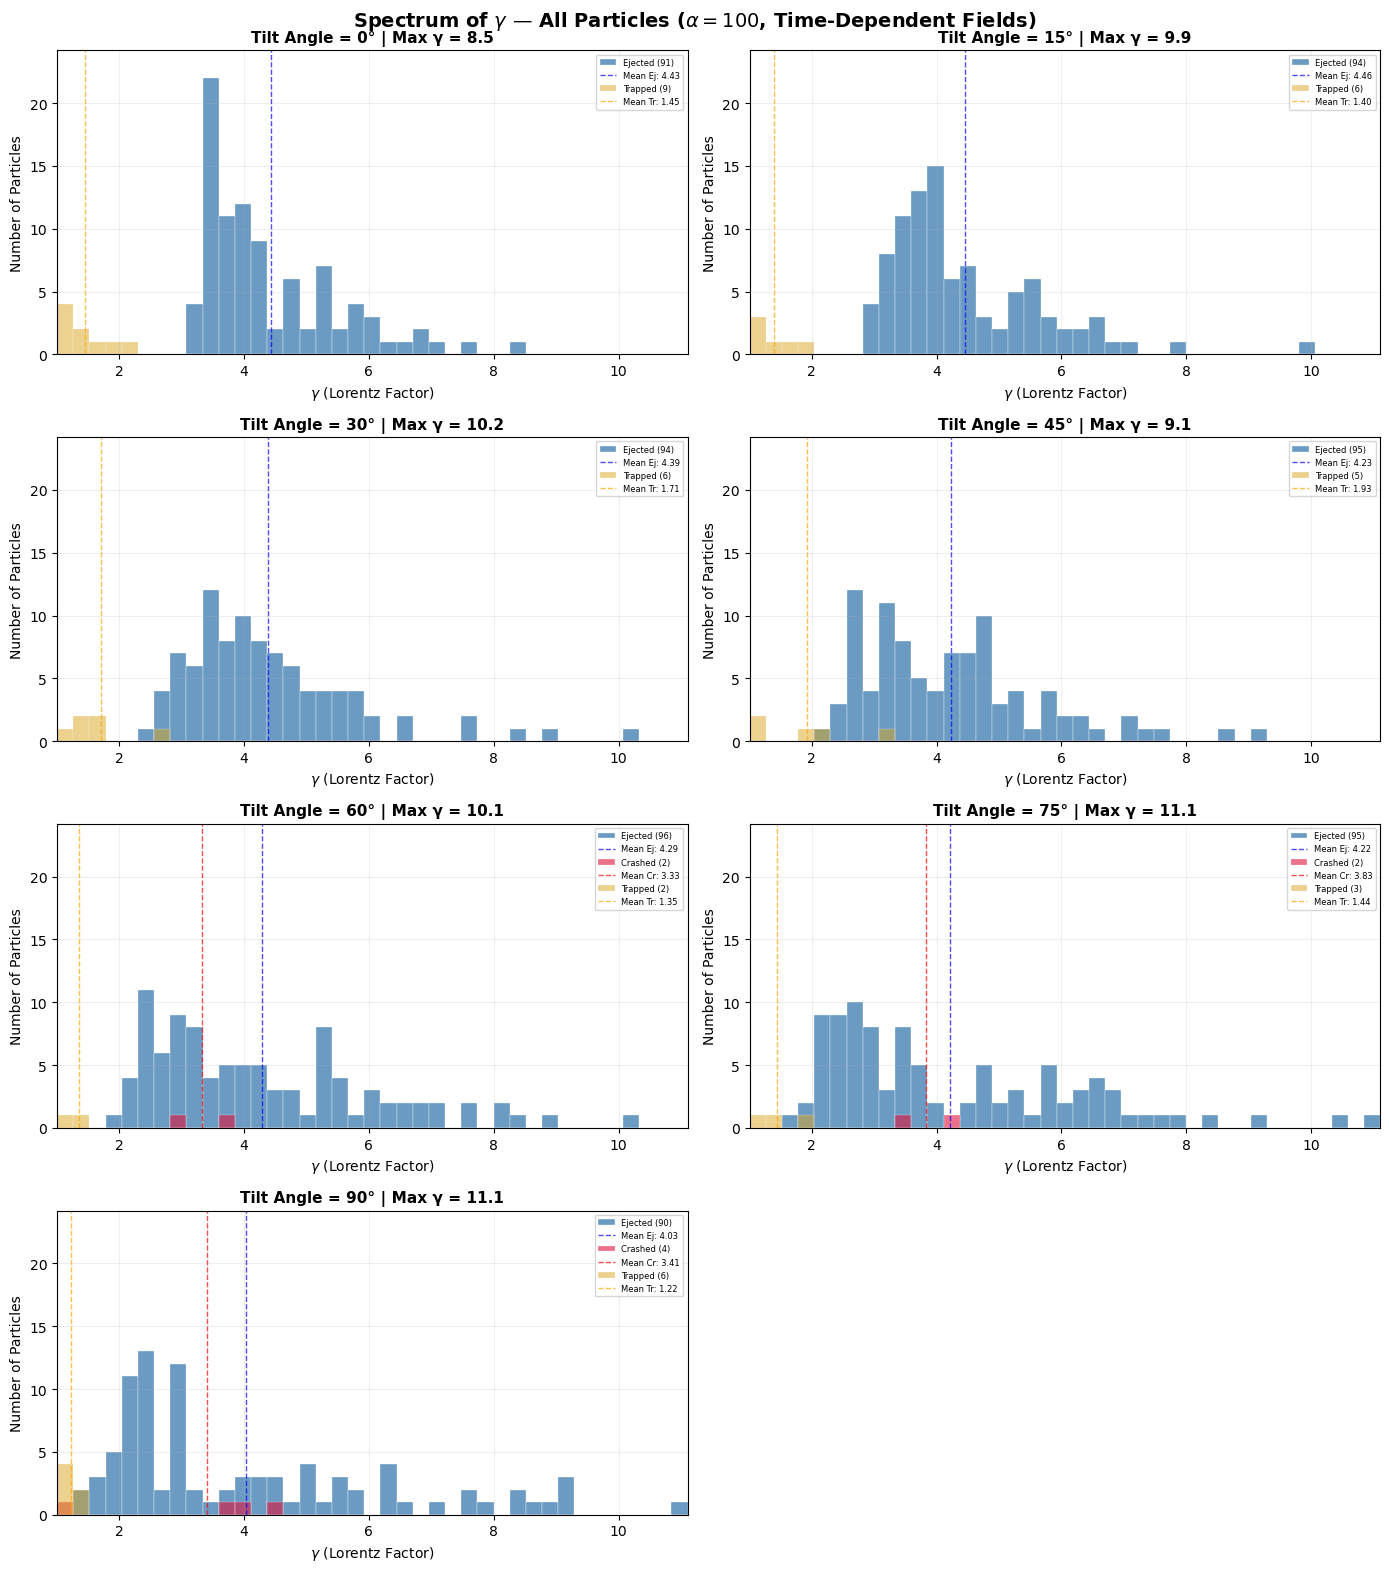

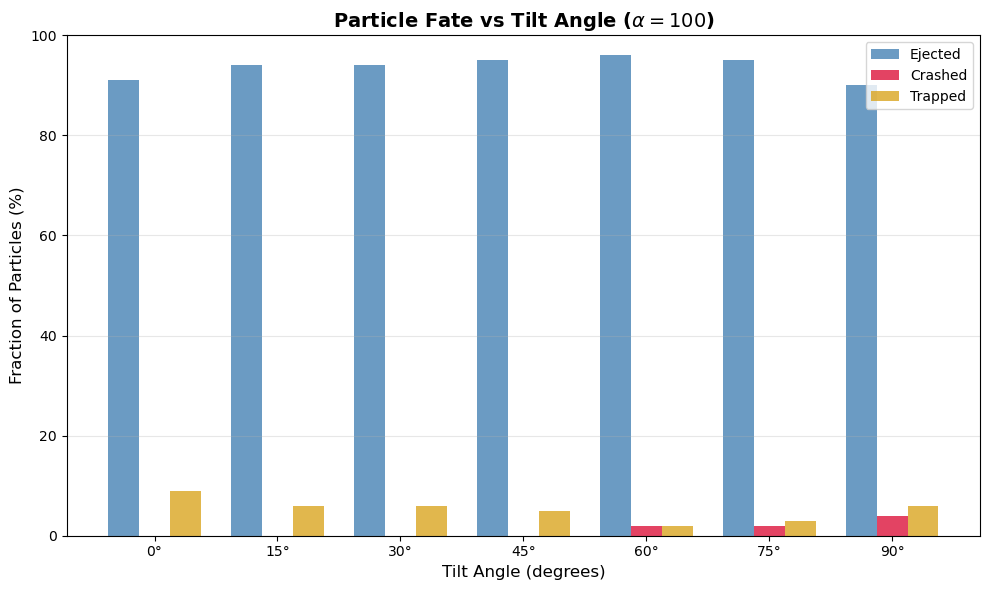


STATISTICS SUMMARY

Tilt Angle 0° (Total: 100 particles):
  Ejected (91): mean γ = 4.4250, min = 3.1820, max = 8.4886
  Crashed: 0 particles
  Trapped (9): mean γ = 1.4454, min = 1.0042, max = 2.2425

Tilt Angle 15° (Total: 100 particles):
  Ejected (94): mean γ = 4.4576, min = 2.9405, max = 9.8754
  Crashed: 0 particles
  Trapped (6): mean γ = 1.4025, min = 1.0729, max = 1.9785

Tilt Angle 30° (Total: 100 particles):
  Ejected (94): mean γ = 4.3856, min = 2.4622, max = 10.1970
  Crashed: 0 particles
  Trapped (6): mean γ = 1.7065, min = 1.2530, max = 2.5940

Tilt Angle 45° (Total: 100 particles):
  Ejected (95): mean γ = 4.2317, min = 2.2831, max = 9.0507
  Crashed: 0 particles
  Trapped (5): mean γ = 1.9294, min = 1.1705, max = 3.1922

Tilt Angle 60° (Total: 100 particles):
  Ejected (96): mean γ = 4.2891, min = 2.0350, max = 10.0726
  Crashed (2): mean γ = 3.3255, min = 2.8580, max = 3.7931
  Trapped (2): mean γ = 1.3519, min = 1.2629, max = 1.4409

Tilt Angle 75° (Total: 100 parti

In [1]:
"""
PLOTTING CELL — GAMMA SPECTRUM AND PARTICLE FATE ANALYSIS

This cell reads the pickle files generated by the simulation and produces:
  1. Histogram grid: gamma (energy) distributions for each tilt angle
  2. Bar chart: fraction of particles that crashed/escaped/were trapped vs tilt angle
  3. Printed statistics summary

All plots use uniform axes for easy comparison across angles.
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================

# Tilt angles that were simulated (in degrees)
angles = [0, 15, 30, 45, 60, 75, 90]

# IMPORTANT: Set this to match the alpha (q/m) used in your simulation
# This value appears in plot titles and axis labels
alpha_value = 1  # <-- CHANGE THIS to match your simulation (e.g., 1, 10, 100)

# Build the label dynamically based on alpha
# Examples:
#   alpha=1   → "α = 1"
#   alpha=100 → "α = 100"
alpha_label = rf"$\alpha = 100$"

# ==========================================
# CREATE FIGURE GRID
# ==========================================
# 4 rows × 2 columns = 8 subplot slots
# We only need 7 (for angles 0-90), so the last one will be hidden
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()  # Converts 2D array of axes to 1D for easy indexing

# ==========================================
# FIRST PASS: COLLECT ALL GAMMA VALUES
# ==========================================
# We need two passes through the data:
#   Pass 1: Read all files, collect every gamma value, determine global min/max
#           and the tallest histogram bar across all plots
#   Pass 2: Plot everything with uniform x and y scales

all_gammas = []           # Every gamma value from every particle (for global min/max)
max_hist_height = 0        # Will store the maximum bar height across all histograms
hist_data = {}             # Dictionary: angle → {gammas_ej, gammas_cr, gammas_tr}

print("Reading data files...")
for ang in angles:
    # Build filename matching the format used when saving
    filename = f"results_angle_{ang}.pkl"
    
    try:
        with open(filename, 'rb') as f:
            data = pickle.load(f)
        
        # ==========================================
        # EXTRACT GAMMA VALUES FOR EACH CATEGORY
        # ==========================================
        # Since we updated simulate_single_particle to return gamma_final as a float,
        # data[category]['gamas'] is now a list of floats (not dictionaries).
        # We filter out None values (shouldn't exist, but safety check).
        
        gammas_ej = np.array([g for g in data['Ejected']['gamas'] 
                             if g is not None])
        gammas_cr = np.array([g for g in data['Crashed']['gamas'] 
                             if g is not None])
        gammas_tr = np.array([g for g in data['Trapped']['gamas'] 
                             if g is not None])
        
        # Add all gamma values to the global collection
        # This lets us find the overall min and max across all angles
        all_gammas.extend(gammas_ej.tolist())
        all_gammas.extend(gammas_cr.tolist())
        all_gammas.extend(gammas_tr.tolist())
        
        # Store for second pass
        hist_data[ang] = {
            'gammas_ej': gammas_ej, 
            'gammas_cr': gammas_cr,
            'gammas_tr': gammas_tr
        }
        
        print(f"  Angle {ang}°: Ejected={len(gammas_ej)}, "
              f"Crashed={len(gammas_cr)}, Trapped={len(gammas_tr)}")
    
    except FileNotFoundError:
        # If a file is missing (e.g., simulation for that angle wasn't run),
        # store empty arrays so the plotting code doesn't crash
        print(f"  ⚠️  File not found: {filename}")
        hist_data[ang] = {
            'gammas_ej': np.array([]), 
            'gammas_cr': np.array([]),
            'gammas_tr': np.array([])
        }

# ==========================================
# CHECK IF WE HAVE ANY DATA
# ==========================================
if len(all_gammas) == 0:
    print("\n❌ No data found! Make sure the pickle files exist in the current directory.")
    print("   Expected files: GJ_results_timedep_angle_0.pkl, ..._angle_15.pkl, etc.")
else:
    print(f"\nTotal particles across all angles: {len(all_gammas)}")
    
    # ==========================================
    # DEFINE UNIFORM BINS AND SCALES
    # ==========================================
    # Use the same bin edges for ALL histograms so they're directly comparable
    global_min = np.min(all_gammas)
    global_max = np.max(all_gammas)
    global_bins = np.linspace(global_min, global_max, 40)  # 40 bins across full range
    
    print(f"Gamma range: {global_min:.2f} to {global_max:.2f}")
    
    # Find the maximum histogram count across ALL plots
    # This ensures all y-axes have the same scale
    for ang in angles:
        for category in ['gammas_ej', 'gammas_cr', 'gammas_tr']:
            gammas = hist_data[ang][category]
            if len(gammas) > 0:
                counts, _ = np.histogram(gammas, bins=global_bins)
                max_hist_height = max(max_hist_height, counts.max())
    
    # Add 10% headroom so the tallest bar doesn't touch the top of the plot
    global_ymax = max_hist_height * 1.1
    
    # ==========================================
    # SECOND PASS: PLOT ALL HISTOGRAMS
    # ==========================================
    for idx, ang in enumerate(angles):
        ax = axes[idx]  # Get the subplot for this angle
        
        gammas_ej = hist_data[ang]['gammas_ej']
        gammas_cr = hist_data[ang]['gammas_cr']
        gammas_tr = hist_data[ang]['gammas_tr']
        
        total_particles = len(gammas_ej) + len(gammas_cr) + len(gammas_tr)
        
        # Handle empty plots (no data for this angle)
        if total_particles == 0:
            ax.set_title(f"Tilt Angle = {ang}° (no data)", fontsize=11, fontweight='bold')
            ax.set_xlim(global_min, global_max)
            ax.set_ylim(0, global_ymax)
            ax.set_xlabel(r'$\gamma$ (Lorentz Factor)', fontsize=10)
            ax.set_ylabel('Number of Particles', fontsize=10)
            ax.grid(True, alpha=0.2)
            continue
        
        # ==========================================
        # PLOT EJECTED PARTICLES (blue)
        # ==========================================
        if len(gammas_ej) > 0:
            ax.hist(gammas_ej, bins=global_bins, color='steelblue', edgecolor='white', 
                    linewidth=0.3, alpha=0.8, label=f'Ejected ({len(gammas_ej)})')
            # Vertical dashed line at the mean gamma for ejected particles
            ax.axvline(gammas_ej.mean(), color='blue', linestyle='--', linewidth=1, alpha=0.7,
                      label=f'Mean Ej: {gammas_ej.mean():.2f}')
        
        # ==========================================
        # PLOT CRASHED PARTICLES (red)
        # ==========================================
        if len(gammas_cr) > 0:
            ax.hist(gammas_cr, bins=global_bins, color='crimson', edgecolor='white', 
                    linewidth=0.3, alpha=0.6, label=f'Crashed ({len(gammas_cr)})')
            if len(gammas_cr) > 0:
                ax.axvline(gammas_cr.mean(), color='red', linestyle='--', linewidth=1, alpha=0.7,
                          label=f'Mean Cr: {gammas_cr.mean():.2f}')
        
        # ==========================================
        # PLOT TRAPPED PARTICLES (gold)
        # ==========================================
        if len(gammas_tr) > 0:
            ax.hist(gammas_tr, bins=global_bins, color='goldenrod', edgecolor='white', 
                    linewidth=0.3, alpha=0.5, label=f'Trapped ({len(gammas_tr)})')
            if len(gammas_tr) > 0:
                ax.axvline(gammas_tr.mean(), color='orange', linestyle='--', linewidth=1, alpha=0.7,
                          label=f'Mean Tr: {gammas_tr.mean():.2f}')
        
        # ==========================================
        # REFERENCE LINES
        # ==========================================
        # Thin dotted lines marking the global min and max gamma values
        # Helps see where each angle's distribution sits relative to the full range
        ax.axvline(global_min, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        ax.axvline(global_max, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        
        # ==========================================
        # UNIFORM AXES (same scale for all subplots)
        # ==========================================
        ax.set_xlim(global_min, global_max)
        ax.set_ylim(0, global_ymax)
        
        ax.set_xlabel(r'$\gamma$ (Lorentz Factor)', fontsize=10)
        ax.set_ylabel('Number of Particles', fontsize=10)
        
        # ==========================================
        # TITLE WITH KEY STATISTICS
        # ==========================================
        # Show the maximum gamma achieved at this angle (usually from ejected particles)
        if len(gammas_ej) > 0:
            title = f"Tilt Angle = {ang}° | Max γ = {gammas_ej.max():.1f}"
        elif len(gammas_cr) > 0:
            title = f"Tilt Angle = {ang}° | Max γ (Cr) = {gammas_cr.max():.1f}"
        else:
            title = f"Tilt Angle = {ang}° | Max γ (Tr) = {gammas_tr.max():.1f}"
        
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.legend(fontsize=6, loc='upper right')
        ax.grid(True, alpha=0.2)
    
    # ==========================================
    # HIDE UNUSED SUBPLOT
    # ==========================================
    # We have 8 subplot slots (4×2) but only 7 angles
    # Hide the 8th one so it doesn't show as empty
    axes[7].set_visible(False)
    
    # ==========================================
    # MAIN TITLE AND SAVE
    # ==========================================
    # The title includes alpha so you know which simulation this is
    fig.suptitle(rf'Spectrum of $\gamma$ — All Particles ({alpha_label}, Time-Dependent Fields)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('espectro_gamma_all_angles.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==========================================
    # ADDITIONAL PLOT: PARTICLE FATE FRACTIONS
    # ==========================================
    # This bar chart shows, for each tilt angle, what percentage of particles
    # ended up in each category (Ejected, Crashed, Trapped)
    
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    
    categories = ['Ejected', 'Crashed', 'Trapped']
    colors = ['steelblue', 'crimson', 'goldenrod']
    
    x = np.arange(len(angles))     # Bar positions: 0, 1, 2, ..., 6
    width = 0.25                    # Width of each bar (three bars per angle)
    
    for i, (cat, color) in enumerate(zip(categories, colors)):
        fractions = []
        for ang in angles:
            # Get counts for this angle
            n_ej = len(hist_data[ang]['gammas_ej'])
            n_cr = len(hist_data[ang]['gammas_cr'])
            n_tr = len(hist_data[ang]['gammas_tr'])
            total = n_ej + n_cr + n_tr
            
            if total > 0:
                if cat == 'Ejected':
                    frac = n_ej / total
                elif cat == 'Crashed':
                    frac = n_cr / total
                else:  # Trapped
                    frac = n_tr / total
            else:
                frac = 0
            
            fractions.append(frac * 100)  # Convert fraction to percentage
        
        # Plot bars for this category, offset by i*width so they don't overlap
        ax2.bar(x + i*width, fractions, width, label=cat, color=color, alpha=0.8)
    
    # Axis labels and formatting
    ax2.set_xlabel('Tilt Angle (degrees)', fontsize=12)
    ax2.set_ylabel('Fraction of Particles (%)', fontsize=12)
    ax2.set_title(rf'Particle Fate vs Tilt Angle ({alpha_label})', fontsize=14, fontweight='bold')
    
    # Center the x-tick labels under each group of 3 bars
    ax2.set_xticks(x + width)
    ax2.set_xticklabels([f"{a}°" for a in angles])
    
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')  # Only horizontal grid lines
    ax2.set_ylim(0, 100)                 # Percentages from 0 to 100%
    
    plt.tight_layout()
    plt.savefig('particle_fate_fractions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==========================================
    # STATISTICS SUMMARY (printed to console)
    # ==========================================
    # Detailed breakdown of gamma statistics for each angle and category
    print("\n" + "="*60)
    print("STATISTICS SUMMARY")
    print("="*60)
    
    for ang in angles:
        gammas_ej = hist_data[ang]['gammas_ej']
        gammas_cr = hist_data[ang]['gammas_cr']
        gammas_tr = hist_data[ang]['gammas_tr']
        
        total = len(gammas_ej) + len(gammas_cr) + len(gammas_tr)
        
        print(f"\nTilt Angle {ang}° (Total: {total} particles):")
        
        # Ejected statistics
        if len(gammas_ej) > 0:
            print(f"  Ejected ({len(gammas_ej)}): mean γ = {gammas_ej.mean():.4f}, "
                  f"min = {gammas_ej.min():.4f}, max = {gammas_ej.max():.4f}")
        else:
            print(f"  Ejected: 0 particles")
        
        # Crashed statistics
        if len(gammas_cr) > 0:
            print(f"  Crashed ({len(gammas_cr)}): mean γ = {gammas_cr.mean():.4f}, "
                  f"min = {gammas_cr.min():.4f}, max = {gammas_cr.max():.4f}")
        else:
            print(f"  Crashed: 0 particles")
        
        # Trapped statistics
        if len(gammas_tr) > 0:
            print(f"  Trapped ({len(gammas_tr)}): mean γ = {gammas_tr.mean():.4f}, "
                  f"min = {gammas_tr.min():.4f}, max = {gammas_tr.max():.4f}")
        else:
            print(f"  Trapped: 0 particles")